# DDPM : apprendre et échantillonner en 2D

Apprentissage réel d’un débruiteur sur huit amas synthétiques, environ quelques secondes sur CPU. Aucun modèle d’image ni conditionnement textuel. Voir ateliers_avances.md pour les équations.

## 1. Données et processus direct

Le produit des alpha devient proche de zéro au dernier temps. Les x_t sont construits directement depuis x_0 et un bruit connu.

In [1]:
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt
torch.set_num_threads(1); torch.manual_seed(42)
angles = torch.arange(8)*2*torch.pi/8
centers = torch.stack([torch.cos(angles),torch.sin(angles)],1)*1.5
def samples(n):
    return centers[torch.randint(8,(n,))] + .09*torch.randn(n,2)
data = samples(3000)
steps = 100
beta = torch.linspace(.0001,.12,steps)
alpha = 1-beta; abar = torch.cumprod(alpha,0)
assert abar[-1] < .01
def time_features(t):
    z = t.float()/steps
    return torch.stack([z,torch.sin(2*torch.pi*z),torch.cos(2*torch.pi*z)],1)
net = nn.Sequential(nn.Linear(5,64),nn.SiLU(),nn.Linear(64,64),nn.SiLU(),nn.Linear(64,2))
opt = torch.optim.Adam(net.parameters(),lr=.002)
history = []
for iteration in range(1200):
    x0 = data[torch.randint(len(data),(128,))]
    t = torch.randint(steps,(len(x0),))
    noise = torch.randn_like(x0)
    xt = abar[t,None].sqrt()*x0+(1-abar[t,None]).sqrt()*noise
    estimate = net(torch.cat([xt,time_features(t)],1))
    loss = nn.functional.mse_loss(estimate,noise)
    opt.zero_grad(); loss.backward(); opt.step()
    if iteration%100==0: history.append(loss.item())
print('Loss train aux étapes 0,100,… :',np.round(history,3))

Loss train aux étapes 0,100,… : [1.052 0.353 0.286 0.431 0.303 0.299 0.353 0.315 0.451 0.412 0.413 0.323]


## 2. Test de débruitage et sampling inverse

Le test utilise des points frais. Le sampler part d’un bruit indépendant, applique la moyenne DDPM et sa variance postérieure, puis supprime le bruit au dernier pas.

In [2]:
net.eval()
with torch.no_grad():
    x0 = samples(1000); t = torch.randint(steps,(1000,)); noise = torch.randn_like(x0)
    xt = abar[t,None].sqrt()*x0+(1-abar[t,None]).sqrt()*noise
    test_loss = nn.functional.mse_loss(net(torch.cat([xt,time_features(t)],1)),noise).item()
    baseline = noise.square().mean().item()
    generated = torch.randn(1200,2)
    for ti in reversed(range(steps)):
        t = torch.full((len(generated),),ti,dtype=torch.long)
        eps = net(torch.cat([generated,time_features(t)],1))
        mean = (generated-beta[ti]/(1-abar[ti]).sqrt()*eps)/alpha[ti].sqrt()
        previous = abar[ti-1] if ti > 0 else torch.tensor(1.)
        posterior_variance = beta[ti]*(1-previous)/(1-abar[ti])
        generated = mean + posterior_variance.sqrt()*torch.randn_like(mean) if ti > 0 else mean
assert test_loss < baseline and torch.isfinite(generated).all()
distance = torch.cdist(generated,centers)
print({'MSE bruit test':test_loss,'baseline zéro':baseline,'modes les plus proches présents':len(distance.argmin(1).unique()),
       'distance moyenne au centre le plus proche':distance.min(1).values.mean().item()})

{'MSE bruit test': 0.3015585243701935, 'baseline zéro': 0.9828495979309082, 'modes les plus proches présents': 8, 'distance moyenne au centre le plus proche': 0.36550164222717285}


## 3. Comparaison visuelle

Conserver les mêmes axes pour comparer structure et dispersion. Couvrir tous les centres ne prouve pas que les densités sont correctement reproduites.

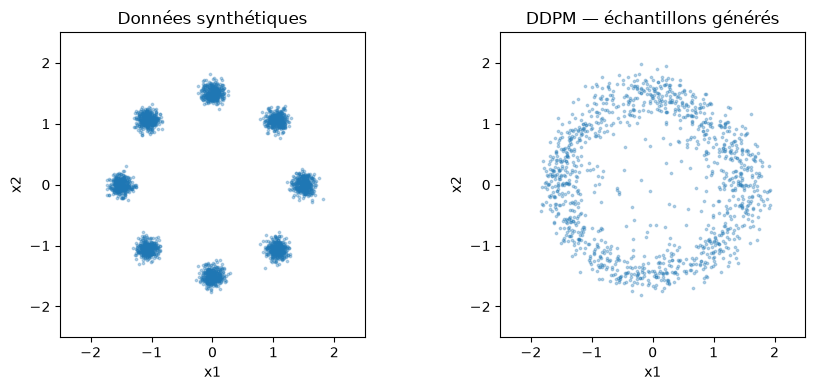

In [3]:
fig,axes = plt.subplots(1,2,figsize=(9,4))
for ax,points,title in zip(axes,[data,generated],['Données synthétiques','DDPM — échantillons générés']):
    ax.scatter(points[:,0],points[:,1],s=3,alpha=.3)
    ax.set(xlim=(-2.5,2.5),ylim=(-2.5,2.5),xlabel='x1',ylabel='x2',title=title)
    ax.set_aspect('equal')
plt.tight_layout(); plt.show()

## Exercice

Remplacez time_features par des zéros et réentraînez. Que mesure la loss de bruit, et que ne mesure-t-elle pas ?

In [4]:
# Écrivez votre expérience ici avant de lire la correction.

## Correction et limites

Elle mesure une erreur de prédiction conditionnée par le processus de bruitage. Elle ne mesure pas directement diversité, fidélité ou mémorisation. Retirer le temps mélange des tâches de débruitage différentes. Comparer MSE, densité et modes avec les mêmes graines et un test fixe.